In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 운영 체제와 상호 작용하는 함수(예: 파일 처리)를 불러옴.
import os

# 시간 관련 함수(예: 시간 측정)를 불러옴.
import time

# 객체를 깊은 복사(deep copy)하기 위한 모듈을 불러옴.
import copy

# NumPy 라이브러리를 np 별칭으로 불러옴. 배열 및 수치 연산에 사용함.
import numpy as np

# Matplotlib의 pyplot 모듈을 plt 별칭으로 불러옴. 데이터 시각화에 사용함.
import matplotlib.pyplot as plt

# PyTorch 핵심 라이브러리를 불러옴.
import torch

# TorchVision 라이브러리를 불러옴.
import torchvision

# 신경망 레이어(nn) 모듈을 불러옴.
import torch.nn as nn

# 옵티마이저(optim) 모듈을 불러옴.
import torch.optim as optim

# 학습률 스케줄러(lr_scheduler) 모듈을 불러옴. 학습률 조정에 사용함.
from torch.optim import lr_scheduler

# TorchVision에서 데이터셋, 미리 학습된 모델, 데이터 변환 모듈을 불러옴.
from torchvision import datasets, models, transforms

# PyTorch의 난수 생성기 시드(seed) 값을 0으로 설정했음. 재현성을 보장함.
torch.manual_seed(0)

In [3]:
model = models.vgg19_bn(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:02<00:00, 244MB/s]


In [4]:
# 파일 업로드 창이 열립니다. 여기서 kaggle.json 파일을 선택하여 업로드합니다.
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hansikyung","key":"3ca4ed141d169e306b8330fc7afda057"}'}

In [5]:
!pip install kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ajayrana/hymenoptera-data
!unzip -q hymenoptera-data.zip -d .

Dataset URL: https://www.kaggle.com/datasets/ajayrana/hymenoptera-data
License(s): CC0-1.0
100% 90.2M/90.2M [00:05<00:00, 18.0MB/s]



In [17]:
ddir = 'hymenoptera_data'

# 학습(train)과 검증(val) 데이터셋에 적용할 이미지 전처리(transform)를 딕셔너리 정의함
data_transformers = {
    # 학습 데이터 변환 : 데이터 증강(augmentation) 포함함
    'train' : transforms.Compose([
        # 이미지를 무작위로 자르고 224*224 조절함
        transforms.RandomResizedCrop(224),
        # 이미지를 무작위로 수평 뒤집음.
        transforms.RandomHorizontalFlip(),

        transforms.ToTensor(),
        transforms.Normalize([0.490, 0.449, 0.411], ([0.231, 0.221, 0.230]))
    ]),
    # 검증 데이터 변환: 크기 조정과 정규화만 포함
    'val' : transforms.Compose([
        # 이미지 크기를 224*224 조절함
        transforms.Resize(226),
        transforms.CenterCrop(224),
        # 이미지 중앙응 224*224

        transforms.ToTensor(),
        transforms.Normalize([0.490, 0.449, 0.411], ([0.231, 0.221, 0.230]))
    ])}

# 'train'과 'val' 디렉토리에서 ImageFolder 데이터 셋 로드 >> 해당되는 전처리 적용
img_data = {k : datasets.ImageFolder(os.path.join(ddir, k), data_transformers[k]) for k in ['train', 'val']}
           # os.path.join(ddir, k) >> 'ddir/k' (파일 경로)
           # data_transformers[k] {k는 train, val} 전처리한 데이터

print(img_data)
# ImageFolder 데이터셋 >> DataLoader 객체로 변환
# 배치크기 8 , 데이터 섞기(shuffle) 활성화, 작업자수(num_workds)는 2로 설정

batch_size=8

dloaders = {'train': torch.utils.data.DataLoader(img_data['train'],
                                                 batch_size=batch_size, shuffle=True, num_workers=2),
  'val': torch.utils.data.DataLoader(img_data['val'],
                                                 batch_size=batch_size, shuffle=False, num_workers=2)}

# print(dloaders['train'])

# 학습 및 검증 데이터 셋 전체 이미지 개수(사이즈) 저장
dset_sizes = {x: len(img_data[x]) for x in {'train','val'}}
# dset_sizes  # {'train': 244, 'val': 153}

# 데이터 셋에서 자동으로 추출된 클래스 이름 리스트로 저장
classes = img_data['train'].classes # ['ants', 'bees']

# 학습에 사용할 장치(device) 설정
dvc = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# dvc # device(type='cuda', index=0)

{'train': Dataset ImageFolder
    Number of datapoints: 244
    Root location: hymenoptera_data/train
    StandardTransform
Transform: Compose(
               RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.49, 0.449, 0.411], std=[0.231, 0.221, 0.23])
           ), 'val': Dataset ImageFolder
    Number of datapoints: 153
    Root location: hymenoptera_data/val
    StandardTransform
Transform: Compose(
               Resize(size=226, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               ToTensor()
               Normalize(mean=[0.49, 0.449, 0.411], std=[0.231, 0.221, 0.23])
           )}


In [21]:
import ast
# ast : 파일 내 문자열 tree 구조를 파이썬 데이터 구조인 dict() 형태로 변환해줘요

label_path = '/content/drive/MyDrive/두산로보틱스_딥러닝_컴퓨터비전/9기/9기_컴퓨터비전 응용/컴퓨터비전_응용_9기/강의_9기_AI응용_5차시_CNN 응용_분류 시스템/imagenet1000_clsidx_to_labels.txt'

with open(label_path) as f:
   classes_data = f.read()

classes_dict = ast.literal_eval(classes_data)
# classes_dict

{k: classes_dict[k] for k in list(classes_dict)[:5]}

{0: 'tench, Tinca tinca',
 1: 'goldfish, Carassius auratus',
 2: 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias',
 3: 'tiger shark, Galeocerdo cuvieri',
 4: 'hammerhead, hammerhead shark'}

In [24]:
classes_dict[5]

'electric ray, crampfish, numbfish, torpedo'

In [30]:
# 이미지를 화면에 표시하는 함수(정규화된 이미지 역정규화)
def imageshow(img, text=None):
    img = img.numpy().transpose((1,2,0)) # chw >> hwc
    # 정규화에 사용되었던 RGB 채널별 평균(mean) 정의함
    avg = np.array([0.490, 0.449, 0.411])
    # 정규화에 사용되었던 RGB 채널별 표준편차(steddev) 정의함
    steddev=np.array([0.231, 0.221, 0.230])
    # 역정규화(denormalization) 수행
    img = steddev * img + avg

    # 픽셀값을 [0,1] 범위 내로 clip 함
    img = np.clip(img, 0, 1)
    # 이미지 화면 표시
    plt.imshow(img)

    # 텍스트가 제공된 경우 이미지 제목으로 설정
    if text is not None:
        plt.title(text)

# 학습된 모델의 예측결과를 시각화하는 함수
def visualize_predictions(pretrained_model, max_num_imgs=4):
    torch.manual_seed(1)

    # 모델의 원래 학습 모드 상태를 저장함
    was_model_training = pretrained_model.training

    # 모델을 평가모드로 설정
    pretrained_model.eval()

    # 시각화할 이미지 카운터를 0으로 초기화
    imgs_counter = 0

    fig = plt.figure()

    # gradients 계산 비활성화
    with torch.no_grad():
        # 검증 데이터 활용 ('val')
        for i, (imgs, tgts) in enumerate(dloaders['val']):
            imgs = imgs.to(dvc)
            tgts = tgts.to(dvc)

            # 순전파 수행 >> 예측결과 얻음
            ops = pretrained_model(imgs)

            # 예측결과에서 예측클래스(preds) 찾음
            _, preds = torch.max(ops, 1)

            # 현재 배치 내의 모든 이미지에 대해 순회함
            for j in range(imgs.size()[0]):
                # 이미지 카운터 증가
                imgs_counter += 1

                # 서브플랏 위치를 설정
                ax = plt.subplot(max_num_imgs//2, 2, imgs_counter)

                # 축 표시 끔
                ax.axis('off')

                # 예측 클래스 이름만 제목 설정
                ax.set_title(f'pred: {classes_dict[int(preds[j])]}')

                # 역정규화된 이미지를 화면에 표시
                imageshow(imgs.cpu().data[j])

                # 설정된 최대 이미지 수에 도달했다면
                if imgs_counter == max_num_imgs:
                    # 모델의 모드를 원래 상태로 되돌림
                    pretrained_model.train(mode=was_model_training)
                    # 함수 실행 종료함
                    return

        pretrained_model.train(mode=was_model_training)

In [31]:
model = models.vgg19_bn(pretrained=True)
model = model.to(dvc)

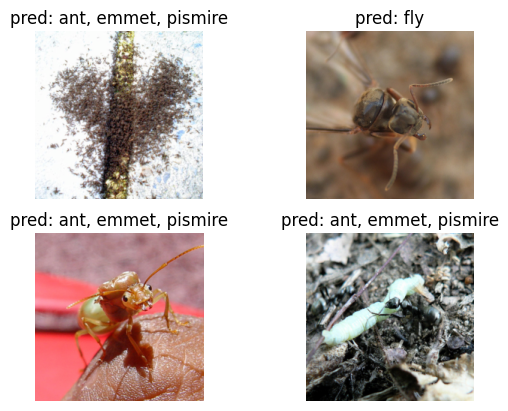

In [32]:
visualize_predictions(model)